# A tearing mode from seed to island

A tearing mode reconnects a current sheet at a resonant surface and grows a
magnetic island. This tutorial seeds one, watches it grow, and extracts a
growth rate from the run. The committed outputs ran on a laptop CPU in under
ten seconds.

The [reduced-MHD model page](../physics/reduced_mhd.md) defines the
equations and the double-Harris equilibrium used here.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import mhx

simulation = mhx.Simulation(
    shape=(64, 64),
    equilibrium=mhx.PeriodicDoubleHarrisEquilibrium(
        width=0.4,
        perturbation_amplitude=4.0e-3,
        perturbation_mode=(2, 1),
    ),
    resistivity=5.0e-3,
    viscosity=5.0e-3,
    dt=2.0e-2,
    t_end=60.0,
    save_every=50,
    verbose=False,
)
result = simulation.run()
result.print_summary()

           MHX result            
┌────────────────┬──────────────┐
│ Final time     │           60 │
│ Saved states   │           60 │
│ Devices        │            1 │
│ Compile time   │      0.174 s │
│ Run time       │      1.310 s │
│ Initial energy │ 3.726865e-01 │
│ Final energy   │ 1.953989e-01 │
│ Max |div B|    │    0.000e+00 │
└────────────────┴──────────────┘

## Isolate the island

The total flux is dominated by the equilibrium sheets. Subtracting the
$y$-averaged profile removes the equilibrium and its slow resistive
spreading, leaving the growing mode.

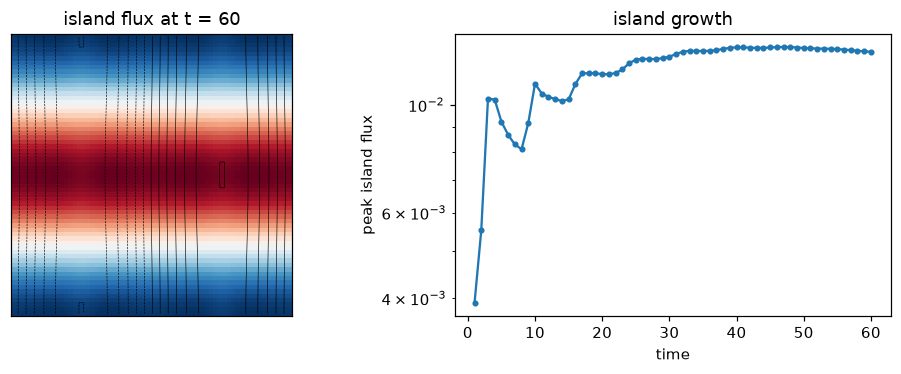

In [2]:
flux = np.asarray(result.trajectory.states.psi)
times = np.asarray(result.trajectory.times)
island = flux - flux.mean(axis=2, keepdims=True)
amplitude = np.abs(island).max(axis=(1, 2))

figure, axes = plt.subplots(1, 2, figsize=(9, 3.5), dpi=110)
scale = np.abs(island[-1]).max()
axes[0].imshow(
    island[-1].T, origin="lower", cmap="RdBu_r", vmin=-scale, vmax=scale
)
axes[0].contour(flux[-1].T, colors="black", linewidths=0.4, levels=12)
axes[0].set_title(f"island flux at t = {times[-1]:.0f}")
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[1].semilogy(times, amplitude, marker="o", markersize=3)
axes[1].set_xlabel("time")
axes[1].set_ylabel("peak island flux")
axes[1].set_title("island growth")
figure.tight_layout()

## Fit a growth rate

During the linear phase the amplitude follows $A(t) \approx A_0 e^{\gamma t}$,
so a straight-line fit to $\log A$ measures $\gamma$. Restrict the fit to a
window where the semilog curve is straight.

In [3]:
window = (times >= 10.0) & (times <= 40.0)
gamma, log_a0 = np.polyfit(times[window], np.log(amplitude[window]), 1)
print(f"fitted growth rate gamma = {gamma:.4f} inverse Alfven times")
print(f"growth over the window: {np.exp(gamma * 30.0):.2f}x")

fitted growth rate gamma = 0.0084 inverse Alfven times
growth over the window: 1.29x


This is a demonstration fit at one resolution and one Lundquist number, not
a calibrated tearing rate. The [linear tearing gates](../validation/linear_tearing.md)
compare fitted rates against direct eigenvalue solves with stated tolerances
and fit windows. Read the difference between the two before citing a number.

Continue with [X points, O points, and islands](02_reconnection.ipynb), or
jump to [differentiating a solve](03_gradients.ipynb).